In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error


In [2]:
features_df = pd.read_csv(r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data\processed\features_rr.csv")

y = np.load(r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data\processed\y_labels.npy")

print("Features:", features_df.shape)
print("Labels:", y.shape)

assert len(features_df) == len(y)



Features: (1638, 13)
Labels: (1638,)


In [3]:
X_windows = np.load(r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data\processed\X_windows.npy")

print("Shape:", X_windows.shape)


Shape: (1638, 3750)


In [4]:
print("Total windows:", len(y))
print("Total subjects:", 53)
print("Windows per subject (approx):", 1638 / 53)

Total windows: 1638
Total subjects: 53
Windows per subject (approx): 30.90566037735849


In [5]:
features_df = pd.read_csv(r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data\processed\features_rr.csv")

print("Loaded shape:", features_df.shape)
features_df.head()

Loaded shape: (1638, 13)


,mean,std,skew,kurtosis,rms,ptp,dominant_freq,resp_power,total_power,rr_dominant_freq,rr_resp_power,rr_total_power,RR
0,-0.000089,0.005012,0.232912,-0.641657,0.005013,0.022100,16.281353,0.003186,0.003311,13.676228,0.000574,0.000594,24.0
1,-0.002647,0.019717,-1.241225,3.752492,0.019894,0.126251,17.398293,0.002852,0.003758,16.319873,0.000755,0.001207,24.0
2,-0.000309,0.016524,0.556773,5.411445,0.016527,0.122869,18.173261,0.019921,0.020828,17.198748,0.017672,0.018392,22.0
3,0.000412,0.005961,0.168945,-0.605352,0.005976,0.026902,16.635780,0.001028,0.001355,19.487258,0.000699,0.000739,20.0
4,-0.000665,0.007063,-0.133148,-0.799151,0.007094,0.028969,16.287375,0.002747,0.002827,18.095449,0.000590,0.000623,22.0


In [6]:
X = features_df.drop("RR", axis=1).values
y = features_df["RR"].values

print("Features:", X.shape)
print("Labels:", y.shape)

Features: (1638, 12)
Labels: (1638,)


In [7]:
subjects = np.repeat(np.arange(53), 31)
subjects = subjects[:1638]  # trim extra if any

print("Subjects:", subjects.shape)

Subjects: (1638,)


In [8]:
print("Check lengths:", len(X), len(y), len(subjects))

Check lengths: 1638 1638 1638


In [9]:
gkf = GroupKFold(n_splits=5)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))
])

mae_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=subjects)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)
    print(f"Fold {fold+1} MAE: {mae:.3f} bpm")

print("\nMean MAE:", np.mean(mae_scores))
print("Std MAE:", np.std(mae_scores))

Fold 1 MAE: 2.181 bpm
Fold 2 MAE: 2.092 bpm
Fold 3 MAE: 1.958 bpm
Fold 4 MAE: 2.469 bpm
Fold 5 MAE: 1.993 bpm

Mean MAE: 2.138530465677934
Std MAE: 0.18276061331078972


In [10]:
pipeline.fit(X, y)
y_pred_full = pipeline.predict(X)  # Using RF pipeline fitted on full data

In [11]:
feature_names = features_df.drop("RR", axis=1).columns
importances = pipeline.named_steps['model'].feature_importances_

# Create DataFrame
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=True)

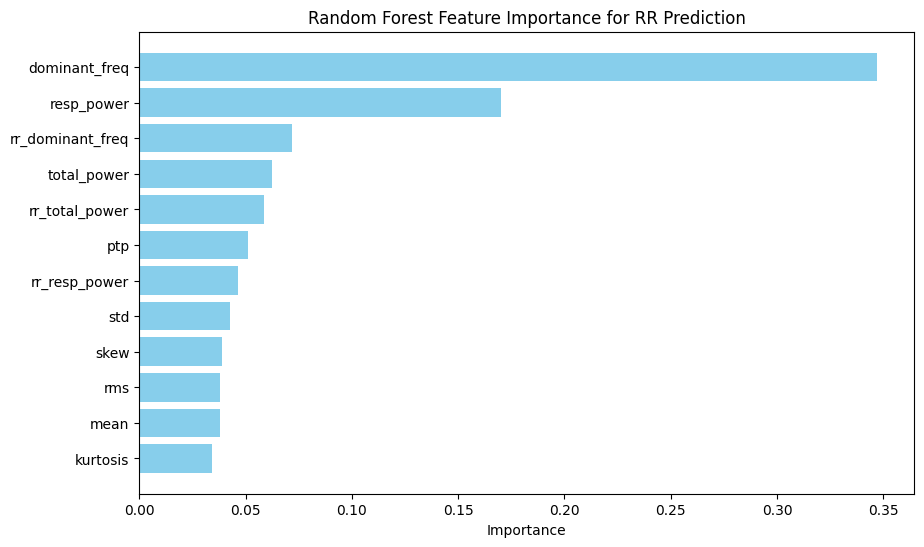

In [12]:
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='skyblue')
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance for RR Prediction")
plt.show()

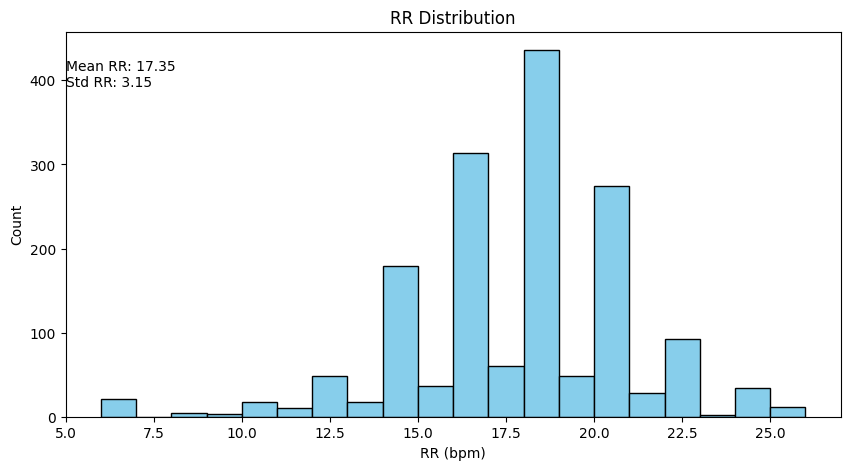

In [13]:
plt.figure(figsize=(10,5))
plt.hist(y, bins=20, color='skyblue', edgecolor='black')
plt.title("RR Distribution")
plt.xlabel("RR (bpm)")
plt.ylabel("Count")
plt.text(5, max(np.histogram(y, bins=20)[0])*0.9, f"Mean RR: {y.mean():.2f}\nStd RR: {y.std():.2f}", fontsize=10, ha='left')
plt.show()

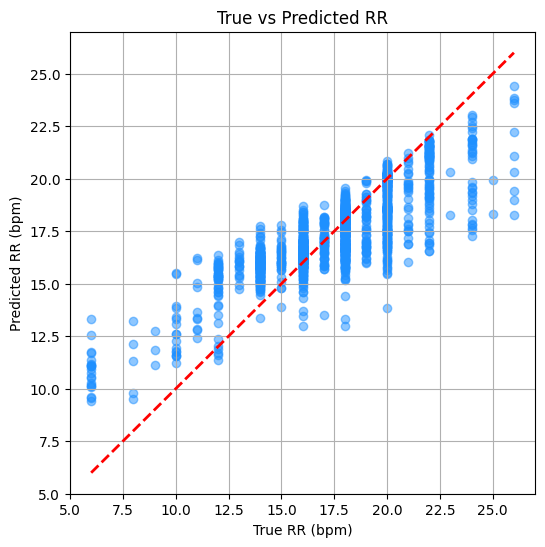

In [14]:
# True vs predicted RR
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred_full, alpha=0.5, color='dodgerblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("True RR (bpm)")
plt.ylabel("Predicted RR (bpm)")
plt.title("True vs Predicted RR")
plt.grid(True)
plt.show()

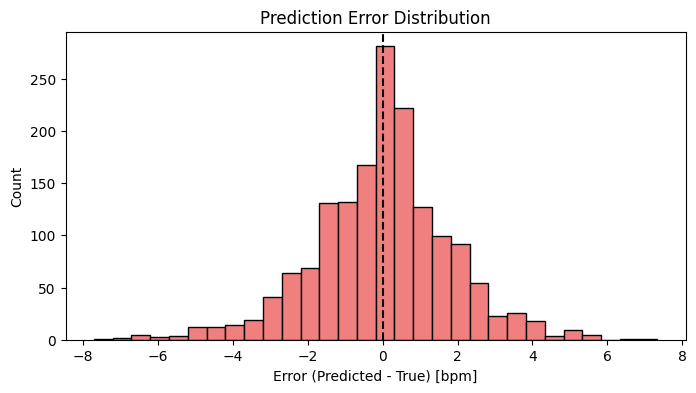

In [15]:
errors = y_pred_full - y

plt.figure(figsize=(8,4))
plt.hist(errors, bins=30, color='lightcoral', edgecolor='black')
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Predicted - True) [bpm]")
plt.ylabel("Count")
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [19]:
import os
import joblib

# ---------------------------
# Saving the trained pipeline
# ---------------------------

# Save the trained pipeline
model_path = r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models\RF_rr_pipeline.pkl"
joblib.dump(pipeline, model_path)

print("Model saved successfully at:", model_path)

Model saved successfully at: C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models\RF_rr_pipeline.pkl
